In [13]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt

gs_path = "gs://weatherbench2/datasets/era5/1959-2022-6h-128x64_equiangular_with_poles_conservative.zarr/"
# gs_path = "gs://weatherbench2/datasets/era5/1959-2022-6h-1440x721.zarr/"

variables_no_level = [
    "2m_temperature",
    "10m_wind_speed",
]

variables_500_level = [
    "geopotential",
]

variables_700_level = [
    "specific_humidity",
]

variables_850_level = [
    "temperature",
]

In [2]:
dataset = xr.open_dataset(gs_path, engine='zarr')
print(dataset)

<xarray.Dataset>
Dimensions:                                           (time: 92040,
                                                       longitude: 128,
                                                       latitude: 64, level: 13)
Coordinates:
  * latitude                                          (latitude) float64 -90....
  * level                                             (level) int64 50 ... 1000
  * longitude                                         (longitude) float64 0.0...
  * time                                              (time) datetime64[ns] 1...
Data variables: (12/38)
    10m_u_component_of_wind                           (time, longitude, latitude) float32 ...
    10m_v_component_of_wind                           (time, longitude, latitude) float32 ...
    10m_wind_speed                                    (time, longitude, latitude) float32 ...
    2m_temperature                                    (time, longitude, latitude) float32 ...
    angle_of_sub_gridscale_o

In [3]:
dataset_no_level = dataset[variables_no_level]
dataset_500_level = dataset[variables_500_level].sel(level=500).drop('level')
dataset_700_level = dataset[variables_700_level].sel(level=700).drop('level')
dataset_850_level = dataset[variables_850_level].sel(level=850).drop('level')

filtered_dataset = xr.merge([dataset_no_level, dataset_500_level, dataset_700_level, dataset_850_level])


filtered_dataset = filtered_dataset.rename_vars({
    '2m_temperature': 't2m',
    '10m_wind_speed': 'ws10',
    'geopotential': 'z500',
    'specific_humidity': 'q700',
    'temperature': 't850'
})

print(filtered_dataset)

<xarray.Dataset>
Dimensions:    (time: 92040, longitude: 128, latitude: 64)
Coordinates:
  * latitude   (latitude) float64 -90.0 -87.14 -84.29 ... 84.29 87.14 90.0
  * longitude  (longitude) float64 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
  * time       (time) datetime64[ns] 1959-01-02 ... 2021-12-31T18:00:00
Data variables:
    t2m        (time, longitude, latitude) float32 ...
    ws10       (time, longitude, latitude) float32 ...
    z500       (time, longitude, latitude) float32 ...
    q700       (time, longitude, latitude) float32 ...
    t850       (time, longitude, latitude) float32 ...


In [4]:
sample = filtered_dataset.isel(time=0)
print(sample.z500.values.shape)
print(sample.t2m.values.shape)
print(sample.ws10.values.shape)
print(sample.q700.values.shape)
print(sample.t850.values.shape)

(128, 64)
(128, 64)
(128, 64)
(128, 64)
(128, 64)


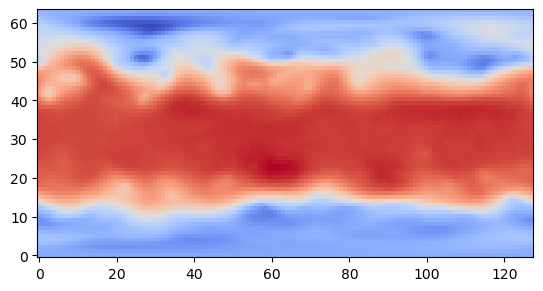

In [5]:
z500_img = sample.z500.values.transpose(1, 0)
z500_img = np.roll(z500_img, 64, axis=1)
plt.imshow(z500_img, origin='lower', cmap='coolwarm')
plt.show()

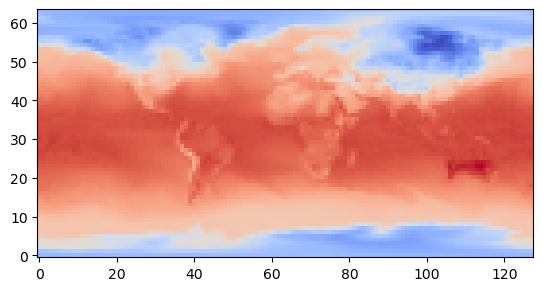

In [6]:
t2m_img = sample.t2m.values.transpose(1, 0) - 273.15
t2m_img = np.roll(t2m_img, 64, axis=1)
plt.imshow(t2m_img, origin='lower', cmap='coolwarm')
plt.show()

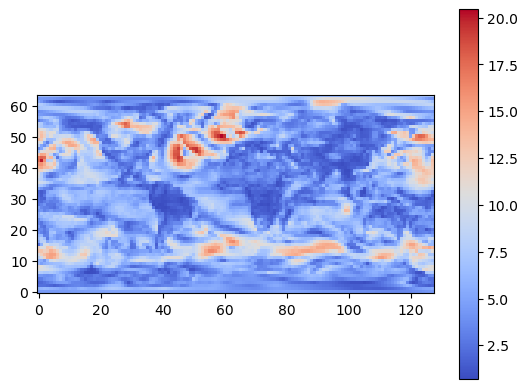

In [7]:
ws10_img = sample.ws10.values.transpose(1, 0)
ws10_img = np.roll(ws10_img, 64, axis=1)
plt.imshow(ws10_img, origin='lower', cmap='coolwarm')
plt.colorbar()
plt.show()

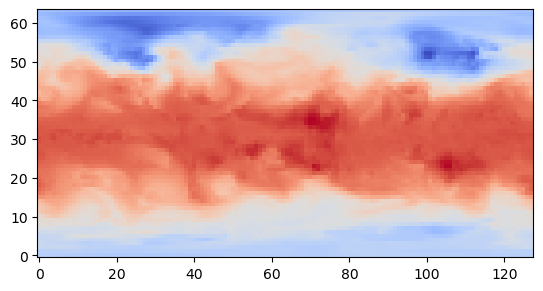

In [8]:
t850_img = sample.t850.values.transpose(1, 0) - 273.15
t850_img = np.roll(t850_img, 64, axis=1)
plt.imshow(t850_img, origin='lower', cmap='coolwarm')
plt.show()

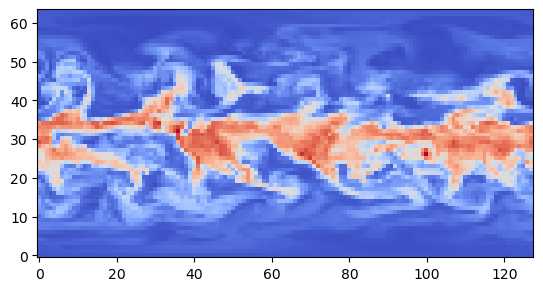

In [9]:
q700_img = sample.q700.values.transpose(1, 0)
q700_img = np.roll(q700_img, 64, axis=1)
plt.imshow(q700_img, origin='lower', cmap='coolwarm')
plt.show()